# Parallel tempering on a bimodal target


## 1. Setup


In [181]:
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import norm

import seaborn as sns
sns.set_theme(context='notebook', style='white', font_scale=1.05)

stamp = datetime.now().strftime('%Y%m%d_%H%M%S')

#figures accumulate here and are written to a single PDF at the end
ALL_FIGS = []

#a shared palette, so every figure names the same thing the same colour
SEO_colour = '#3b5bdb'
DEO_colour = '#e8590c'
control_colour = '#2f9e44'
truth_colour = '#c92a2a'

OUTPUT_ROOT = Path('output')


def plot_path(filename):
    """Full path for a figure. Each run gets its own folder, named by its timestamp."""
    directory = OUTPUT_ROOT / stamp
    directory.mkdir(parents=True, exist_ok=True)
    return directory / filename


print(f'run {stamp}')

run 20260902_164654


## 2. Settings


In [182]:
d = 25
s_1 = 0.2
s_2 = 0.3

num_chains = 48
beta_min = 1e-3

iterations = 15_500
exploration_moves = 32
n_runs = 6

coordinate_of_interest = 2
sigma_0 = 1.0

print(f'{d}-dimensional target, {num_chains} chains, {iterations:,} scans x '
      f'{exploration_moves} moves, {n_runs} runs')
print(f'density evaluations per sampler run: '
      f'{n_runs * iterations * exploration_moves * num_chains:,.0f}')

25-dimensional target, 48 chains, 15,500 scans x 32 moves, 6 runs
density evaluations per sampler run: 142,848,000


## 3. The target distribution


In [183]:
nu_1 = +np.ones(d)
nu_2 = -np.ones(d)


def log_target(x):
    diff_1 = x - nu_1
    diff_2 = x - nu_2

    sq_1 = np.einsum('...i,...i->...', diff_1, diff_1)
    sq_2 = np.einsum('...i,...i->...', diff_2, diff_2)

    log_component_1 = -0.5*d*np.log(2*np.pi*s_1**2) - sq_1/(2*s_1**2)
    log_component_2 = -0.5*d*np.log(2*np.pi*s_2**2) - sq_2/(2*s_2**2)

    return np.logaddexp(np.log(0.5) + log_component_1,
                        np.log(0.5) + log_component_2)


mode_split = 1 - 2*(s_1/(s_1 + s_2))

print(f'log_target at the narrow mode centre: {log_target(nu_1):.2f}')
print(f'log_target at the wide mode centre:   {log_target(nu_2):.2f}')
print(f'samples count as "mode A" when coordinate > {mode_split:.2f}')

log_target at the narrow mode centre: 16.57
log_target at the wide mode centre:   6.43
samples count as "mode A" when coordinate > 0.20


### Why the two mode widths matter


In [184]:
mode_weight_distortion = d*abs(np.log(s_2/s_1))

print(f'mode weight distortion = {mode_weight_distortion:.1f} nats '
      f'(d = {d}, s_2/s_1 = {s_2/s_1:.2f})')
print()
print(f'{"beta":>6}{"narrow mode weight, relative to beta=1":>42}')
for beta in (1.0, 0.9, 0.7, 0.5, 0.2, 0.0):
    print(f'{beta:>6.1f}{(s_1/s_2)**((1-beta)*d):>42.2e}')

if mode_weight_distortion > 5:
    print('\npast ~5 nats, and the single-Gaussian reference does not cancel it,')
    print('so expect each beta = 1 chain to stay in whichever mode it started in')

mode weight distortion = 10.1 nats (d = 25, s_2/s_1 = 1.50)

  beta    narrow mode weight, relative to beta=1
   1.0                                  1.00e+00
   0.9                                  3.63e-01
   0.7                                  4.78e-02
   0.5                                  6.29e-03
   0.2                                  3.01e-04
   0.0                                  3.96e-05

past ~5 nats, and the single-Gaussian reference does not cancel it,
so expect each beta = 1 chain to stay in whichever mode it started in


## 4. The annealing path and the reference


In [185]:
def gaussian_reference(sigma):
    """log density of N(0, sigma^2 I), batched like log_target."""
    def log_reference(x):
        sq = np.einsum('...i,...i->...', x, x)
        return -0.5*d*np.log(2*np.pi*sigma**2) - sq/(2*sigma**2)
    return log_reference


def gaussian_path_sigma(sigma):
    """Width of pi_beta along the path towards N(0, sigma^2 I)."""
    target_var = 0.5*(s_1**2 + s_2**2)      #mean component variance of the target
    def path_sigma(beta):
        beta = np.asarray(beta, dtype=float)
        return 1.0/np.sqrt((1-beta)/sigma**2 + beta/target_var)
    return path_sigma

### Install the reference


In [186]:
log_reference = gaussian_reference(sigma_0)
path_sigma = gaussian_path_sigma(sigma_0)

print(f'annealing towards a single Gaussian N(0, {sigma_0}^2 I).')
print(f'path width: {path_sigma(0.0):.3f} at beta = 0  ->  {path_sigma(1.0):.3f} at beta = 1')
print('The mode weight distortion is NOT removed by this choice.')

annealing towards a single Gaussian N(0, 1.0^2 I).
path width: 1.000 at beta = 0  ->  0.255 at beta = 1
The mode weight distortion is NOT removed by this choice.


### The path, drawn


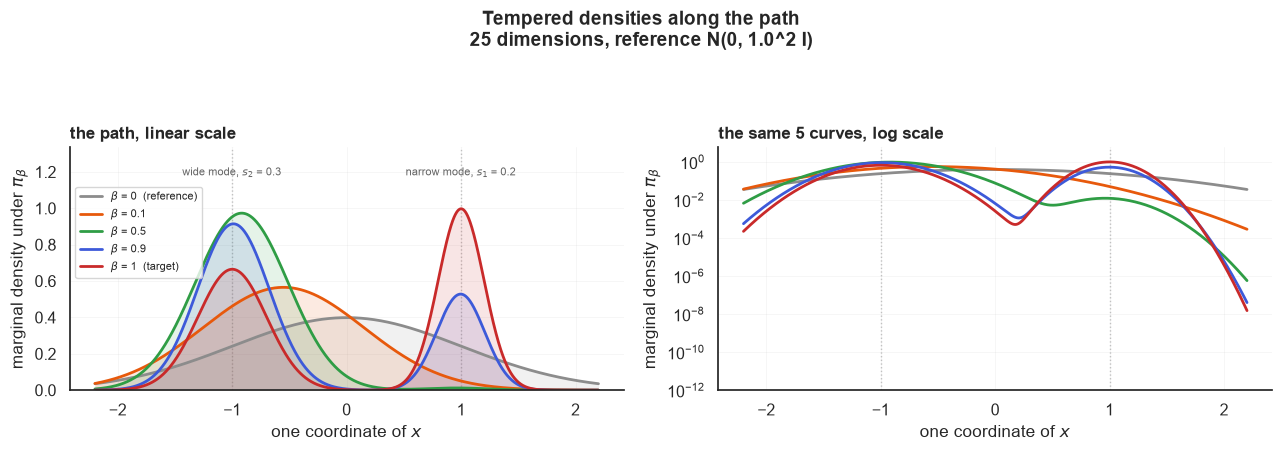

  beta   weight on the narrow mode   width of each component
  0.00                    5.00e-01              1.000, 1.000
  0.10                    4.97e-04              0.542, 0.705
  0.50                    8.52e-03              0.277, 0.406
  0.90                    2.79e-01              0.210, 0.315
  1.00                    5.00e-01              0.200, 0.300


In [187]:
from matplotlib.colors import LinearSegmentedColormap

path_betas = [0.0, 0.1, 0.5, 0.9, 1.0]


def tempered_marginal_parts(beta):
    """(weights, means, sds) of the one-coordinate marginal of pi_beta."""
    s = np.array([s_1, s_2])
    centre = np.array([+1.0, -1.0])         #the modes sit at +1 and -1 in every coordinate
    a = beta/s**2                           #precision contributed by the target
    b = (1-beta)/sigma_0**2                 #precision contributed by the reference
    P = a + b

    log_weight = (beta*np.log(0.5)
                  - 0.5*d*beta*np.log(2*np.pi*s**2)
                  - 0.5*d*(1-beta)*np.log(2*np.pi*sigma_0**2)
                  + 0.5*d*np.log(2*np.pi/P)
                  - 0.5*d*a*b/P)
    log_weight -= log_weight.max()          #the shared constant cancels when normalising
    weight = np.exp(log_weight)

    return weight/weight.sum(), a*centre/P, 1/np.sqrt(P)


def tempered_marginal(beta, grid):
    """Marginal density of one coordinate under pi_beta."""
    weight, mean, sd = tempered_marginal_parts(beta)
    return sum(w*norm.pdf(grid, loc=m, scale=v) for w, m, v in zip(weight, mean, sd))


x_grid = np.linspace(-2.2, 2.2, 1500)
densities = {beta: tempered_marginal(beta, x_grid) for beta in path_betas}

path_cmap = LinearSegmentedColormap.from_list(
    'path', ['0.55', DEO_colour, control_colour, SEO_colour, truth_colour])
path_colours = path_cmap(np.linspace(0, 1, len(path_betas)))

fig_path, axes_path = plt.subplots(1, 2, figsize=(13, 4.6))

for beta, colour in zip(path_betas, path_colours):
    density = densities[beta]
    label = rf'$\beta$ = {beta:g}'
    label += {0.0: '  (reference)', 1.0: '  (target)'}.get(beta, '')
    for ax in axes_path:
        ax.plot(x_grid, density, color=colour, lw=2, label=label)
    axes_path[0].fill_between(x_grid, density, color=colour, alpha=0.12, lw=0)

for ax in axes_path:
    for centre in (-1.0, +1.0):
        ax.axvline(centre, color='0.75', ls=':', lw=1, zorder=0)
    ax.set_xlabel(r'one coordinate of $x$')
    ax.set_ylabel(r'marginal density under $\pi_\beta$')
    ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

peak = max(density.max() for density in densities.values())
for centre, name in [(-1.0, f'wide mode, $s_2$ = {s_2}'),
                     (+1.0, f'narrow mode, $s_1$ = {s_1}')]:
    axes_path[0].text(centre, 1.20*peak, name, ha='center', va='center',
                      fontsize=8, color='0.4')

axes_path[0].set_ylim(0, 1.34*peak)
axes_path[0].legend(fontsize=8, loc='upper left', bbox_to_anchor=(0.0, 0.86))
axes_path[0].set_title('the path, linear scale', loc='left', fontweight='bold')

axes_path[1].set_yscale('log')
axes_path[1].set_ylim(1e-12*peak, 6*peak)
axes_path[1].set_title(f'the same {len(path_betas)} curves, log scale', loc='left',
                       fontweight='bold')

fig_path.suptitle(f'Tempered densities along the path\n{d} dimensions, '
                  f'reference N(0, {sigma_0}^2 I)',
                  fontsize=14, fontweight='bold')
fig_path.tight_layout(rect=[0, 0, 1, 0.90])
ALL_FIGS.append(fig_path)
plt.show()

print(f'{"beta":>6}{"weight on the narrow mode":>28}{"width of each component":>26}')
for beta in path_betas:
    weight, _, sd = tempered_marginal_parts(beta)
    widths = f'{sd[0]:.3f}, {sd[1]:.3f}'
    print(f'{beta:>6.2f}{weight[0]:>28.2e}{widths:>26}')

## 5. The proposal


In [188]:
OPTIMAL_ACCEPTANCE = 0.234        #Roberts, Gelman and Gilks (1997)


def proposal_scale(beta):
    """Per chain random walk step size: one entry per temperature."""
    return 2.38*path_sigma(beta)/np.sqrt(d)


def propose(x, scale, rng):
    """Isotropic Gaussian random walk proposal for every chain at once."""
    return x + scale*rng.standard_normal(size=np.shape(x))


print(f'proposal step: {proposal_scale(0.0):.3f} at beta=0  ->  '
      f'{proposal_scale(1.0):.3f} at beta=1')

proposal step: 0.476 at beta=0  ->  0.121 at beta=1


## 6. The sampler


In [189]:
def exploration_sweep(x, log_pi_x, log_ref_x, beta, scale, n_explore, rng):
    """`n_explore` random walk Metropolis moves on every chain at once."""
    num_temps = beta.size
    noise = rng.standard_normal((n_explore, num_temps, x.shape[1]))
    log_u = np.log(rng.random((n_explore, num_temps)))
    n_accept = np.zeros(num_temps)

    for m in range(n_explore):
        y = x + scale*noise[m]
        log_pi_y = log_target(y)
        log_ref_y = log_reference(y)

        #log of min(1, pi_beta(y)/pi_beta(x)); comparing logs avoids overflow
        log_alpha = ((beta*log_pi_y + (1-beta)*log_ref_y)
                     - (beta*log_pi_x + (1-beta)*log_ref_x))
        accepted = log_u[m] < log_alpha

        n_accept += accepted
        x = np.where(accepted[:, None], y, x)
        log_pi_x = np.where(accepted, log_pi_y, log_pi_x)
        log_ref_x = np.where(accepted, log_ref_y, log_ref_x)

    return x, log_pi_x, log_ref_x, n_accept

In [190]:
def swap_sweep(x, log_pi_x, log_ref_x, replica_at, beta_gap, offset, rng):
    """One sweep of neighbour swaps, starting at chain `offset` and stepping by two."""
    num_temps = beta_gap.size + 1
    pairs = np.arange(offset, num_temps-1, 2)
    if pairs.size == 0:
        return pairs, np.zeros(0, dtype=bool)

    V = log_pi_x - log_ref_x
    log_swap = beta_gap[pairs]*(V[pairs] - V[pairs+1])
    accepted = np.log(rng.random(pairs.size)) < log_swap

    swapped = pairs[accepted]
    if swapped.size:
        lo, hi = swapped, swapped + 1
        x[[lo, hi]] = x[[hi, lo]]
        log_pi_x[[lo, hi]] = log_pi_x[[hi, lo]]
        log_ref_x[[lo, hi]] = log_ref_x[[hi, lo]]
        replica_at[[lo, hi]] = replica_at[[hi, lo]]

    return pairs, accepted

In [191]:
def round_trip_stats(index_process):
    """Round trip diagnostics, following Syed et al. (2022)."""
    n_scans, num_temps = index_process.shape
    n_round_trips = np.zeros(num_temps, dtype=int)
    trip_scans = []
    target_chain = num_temps - 1

    for r in range(num_temps):
        trajectory = index_process[:, r]
        visits = np.flatnonzero((trajectory == 0) | (trajectory == target_chain))
        if visits.size < 2:
            continue

        #label each visit: 0 = at the target end, 1 = at the reference end
        ends = (trajectory[visits] != target_chain).astype(np.int8)
        closes = (ends[1:] == 0) & (ends[:-1] == 1)

        n_round_trips[r] = int(closes.sum())
        if n_round_trips[r]:
            trip_scans.append(visits[1:][closes])

    scans = np.sort(np.concatenate(trip_scans)) if trip_scans else np.array([], dtype=int)
    return n_round_trips, scans.astype(int)

In [192]:
def _parallel_tempering(beta, n_scans, n_explore, deo, rng,
                        burn_frac=0.2, init_sign=None):
    """Shared engine for SEO and DEO parallel tempering."""
    beta = np.asarray(beta, dtype=float)
    num_temps = beta.size
    beta_gap = beta[1:] - beta[:-1]

    scale = proposal_scale(beta).reshape(-1, 1)

    start_mode = (1 if rng.random() > 0.5 else -1) if init_sign is None else init_sign
    x = start_mode*np.ones((num_temps, d))
    log_pi_x = log_target(x)
    log_ref_x = log_reference(x)

    n_accept = np.zeros(num_temps)
    n_swap_proposed = np.zeros(num_temps - 1)
    n_swap_accepted = np.zeros(num_temps - 1)

    #replica_at[j] is the label of the replica sitting on chain j
    replica_at = np.arange(num_temps)
    chain_labels = np.arange(num_temps)

    samples = np.empty((n_scans, d))
    index_process = np.empty((n_scans, num_temps), dtype=np.int32)
    n_burn = int(burn_frac*n_scans)

    for i in range(-n_burn, n_scans):
        recording = i >= 0

        x, log_pi_x, log_ref_x, accepted_now = exploration_sweep(
            x, log_pi_x, log_ref_x, beta, scale, n_explore, rng)

        if recording:
            n_accept += accepted_now

        offset = (i % 2) if deo else int(rng.random() > 0.5)
        pairs, swapped = swap_sweep(x, log_pi_x, log_ref_x, replica_at,
                                    beta_gap, offset, rng)
        if recording and pairs.size:
            n_swap_proposed[pairs] += 1
            n_swap_accepted[pairs] += swapped

        #relabel once, as the recorded index process begins
        if i == -1:
            replica_at = np.arange(num_temps)

        if recording:
            samples[i] = x[-1]                            #the beta = 1 chain
            index_process[i, replica_at] = chain_labels

    n_round_trips, _ = round_trip_stats(index_process)

    return (samples,
            n_accept/(n_scans*n_explore),
            n_swap_accepted/np.maximum(n_swap_proposed, 1),
            n_round_trips.sum()/n_scans,
            index_process)


def SEO_parallel_tempering(beta, n_scans, n_explore, rng=None, **kwargs):
    """Stochastic even-odd: the swap sweep's offset is tossed each scan."""
    return _parallel_tempering(beta, n_scans, n_explore, False,
                               rng or np.random.default_rng(), **kwargs)


def DEO_parallel_tempering(beta, n_scans, n_explore, rng=None, **kwargs):
    """Deterministic even-odd (non-reversible): the offset alternates with the scan."""
    return _parallel_tempering(beta, n_scans, n_explore, True,
                               rng or np.random.default_rng(), **kwargs)

In [193]:
def sample_single_chain(n_scans, rng=None, init_sign=None):
    """Plain random walk Metropolis on the untempered target, as a control."""
    rng = np.random.default_rng() if rng is None else rng

    start_mode = (1 if rng.random() > 0.5 else -1) if init_sign is None else init_sign
    x = start_mode*np.ones(d)
    log_pi_x = log_target(x)

    step = proposal_scale(1.0)               #same optimal scaling, at beta = 1
    noise = step*rng.standard_normal((n_scans, d))
    log_u = np.log(rng.random(n_scans))

    samples = np.empty((n_scans, d))
    n_accept = 0
    for i in range(n_scans):
        y = x + noise[i]
        log_pi_y = log_target(y)
        if log_u[i] < log_pi_y - log_pi_x:
            x, log_pi_x = y, log_pi_y
            n_accept += 1
        samples[i] = x

    return samples, n_accept/n_scans

## 7. The temperature ladder


### Build the ladder


In [194]:
ladder = np.concatenate(([0.0], np.geomspace(beta_min, 1.0, num_chains - 1)))

#both schemes use the SAME ladder, or the comparison is not a comparison
SEO_beta = ladder.copy()
DEO_beta = ladder.copy()

print(f'geometric ladder, {num_chains} chains')
print(f'  beta        {ladder[0]:.3g}, {ladder[1]:.3g}, {ladder[2]:.3g}, ... '
      f'{ladder[-2]:.3g}, {ladder[-1]:.3g}')
print(f'  ratio between neighbouring rungs (beta > 0)   '
      f'{ladder[2]/ladder[1]:.3f}')
print(f'  proposal step   {proposal_scale(0.0):.3f} at beta = 0  ->  '
      f'{proposal_scale(1.0):.3f} at beta = 1')

geometric ladder, 48 chains
  beta        0, 0.001, 0.00116, ... 0.861, 1
  ratio between neighbouring rungs (beta > 0)   1.162
  proposal step   0.476 at beta = 0  ->  0.121 at beta = 1


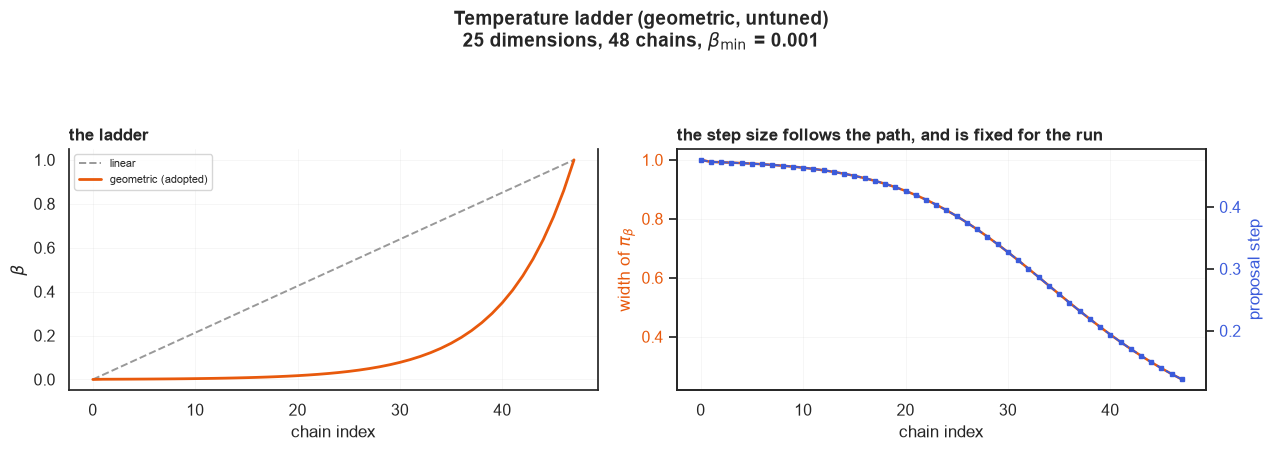

In [195]:
fig_ladder, axes_ladder = plt.subplots(1, 2, figsize=(13, 4.6))

#the ladder, against the obvious alternative
ax = axes_ladder[0]
index = np.arange(num_chains)
ax.plot(index, np.linspace(0, 1, num_chains), color='0.6', ls='--', lw=1.4,
        label='linear')
ax.plot(index, ladder, color=DEO_colour, lw=2, label='geometric (adopted)')
ax.set_xlabel('chain index'); ax.set_ylabel(r'$\beta$')
ax.set_title('the ladder', loc='left', fontweight='bold')
ax.legend(fontsize=8)

ax = axes_ladder[1]
ax.plot(index, path_sigma(ladder), color=DEO_colour, lw=1.8, label=r'$\sigma(\beta)$')
ax.set_xlabel('chain index'); ax.set_ylabel(r'width of $\pi_\beta$', color=DEO_colour)
ax.tick_params(axis='y', labelcolor=DEO_colour)
twin = ax.twinx()
twin.plot(index, proposal_scale(ladder), 's--', ms=3, color=SEO_colour, lw=1.4)
twin.set_ylabel('proposal step', color=SEO_colour)
twin.tick_params(axis='y', labelcolor=SEO_colour)
ax.set_title(r'the step size follows the path, and is fixed for the run',
             loc='left', fontweight='bold')

for ax in axes_ladder:
    ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
    ax.spines[['top']].set_visible(False)

fig_ladder.suptitle('Temperature ladder (geometric, untuned)\n'
                    f'{d} dimensions, {num_chains} chains, '
                    r'$\beta_{\min}$ = ' + f'{beta_min:g}',
                    fontsize=14, fontweight='bold')
fig_ladder.tight_layout(rect=[0, 0, 1, 0.90])
ALL_FIGS.append(fig_ladder)
plt.show()

## 8. Run the experiment


In [196]:
accept_SEO_runs, swap_SEO_runs, tau_SEO_runs = [], [], []
accept_DEO_runs, swap_DEO_runs, tau_DEO_runs = [], [], []
accept_control_runs = []
samples_SEO_runs, samples_DEO_runs, samples_control_runs = [], [], []
start_modes = []

start_time = time.time()
for run in range(n_runs):
    seed = 1000 + 10*run
    start_mode = 1 if run % 2 == 0 else -1
    start_modes.append(start_mode)

    s_SEO, a_SEO, w_SEO, t_SEO, idx_SEO = SEO_parallel_tempering(
        SEO_beta, iterations, exploration_moves,
        rng=np.random.default_rng(seed), init_sign=start_mode)
    s_DEO, a_DEO, w_DEO, t_DEO, idx_DEO = DEO_parallel_tempering(
        DEO_beta, iterations, exploration_moves,
        rng=np.random.default_rng(seed+1), init_sign=start_mode)
    s_ctl, a_ctl = sample_single_chain(
        iterations, rng=np.random.default_rng(seed+2), init_sign=start_mode)

    accept_SEO_runs.append(a_SEO); swap_SEO_runs.append(w_SEO); tau_SEO_runs.append(t_SEO)
    accept_DEO_runs.append(a_DEO); swap_DEO_runs.append(w_DEO); tau_DEO_runs.append(t_DEO)
    accept_control_runs.append(a_ctl)
    samples_SEO_runs.append(s_SEO); samples_DEO_runs.append(s_DEO)
    samples_control_runs.append(s_ctl)

    if run == 0:
        index_SEO, index_DEO = idx_SEO, idx_DEO

    print(f'run {run+1}/{n_runs} (start mode {start_mode:+d}), '
          f'{time.time()-start_time:.1f} s elapsed')

simulation_time = time.time() - start_time

accept_SEO_runs = np.array(accept_SEO_runs); swap_SEO_runs = np.array(swap_SEO_runs)
accept_DEO_runs = np.array(accept_DEO_runs); swap_DEO_runs = np.array(swap_DEO_runs)
tau_SEO_runs = np.array(tau_SEO_runs);       tau_DEO_runs = np.array(tau_DEO_runs)
accept_control_runs = np.array(accept_control_runs)
samples_SEO_runs = np.array(samples_SEO_runs)
samples_DEO_runs = np.array(samples_DEO_runs)
samples_control_runs = np.array(samples_control_runs)

print(f'\n{n_runs} runs x {iterations:,} scans in {simulation_time:.1f} s '
      f'({simulation_time/n_runs:.1f} s per run)')

run 1/6 (start mode +1), 33.5 s elapsed
run 2/6 (start mode -1), 66.8 s elapsed
run 3/6 (start mode +1), 100.0 s elapsed
run 4/6 (start mode -1), 133.0 s elapsed
run 5/6 (start mode +1), 166.1 s elapsed
run 6/6 (start mode -1), 199.1 s elapsed

6 runs x 15,500 scans in 199.1 s (33.2 s per run)


## 9. Reporting across the replicate runs


In [197]:
def across_runs(values, ddof=1):
    """Mean, sample standard deviation and standard error of the mean."""
    v = np.asarray(values, dtype=float)
    sd = v.std(ddof=ddof) if v.size > ddof else 0.0
    return v.mean(), sd, sd/np.sqrt(v.size)


def report_runs(name, values, truth=None, fmt='.4f', width=26):
    """Print the individual runs, then mean, sd and sem on the line below."""
    v = np.asarray(values, dtype=float)
    mean, sd, sem = across_runs(v)

    print(f'{name:<{width}} ' + '  '.join(f'{x:{fmt}}' for x in v))
    summary = f'{"":<{width}} mean {mean:{fmt}}  sd {sd:{fmt}}  sem {sem:{fmt}}'
    if truth is not None:
        summary += f'   truth {truth:{fmt}}'
        if sem > 0:
            summary += f', off by {abs(mean-truth)/sem:.1f} sem'
    print(summary)
    return mean, sd, sem


def gelman_rubin(chains):
    """R-hat across replicate chains; chains[i] is the trace from run i."""
    x = np.asarray(chains, dtype=float)
    n_chains, n_draws = x.shape

    within = x.var(axis=1, ddof=1).mean()
    if within <= 0:
        return np.inf if np.ptp(x.mean(axis=1)) > 0 else 1.0

    between = n_draws*x.mean(axis=1).var(ddof=1)
    var_plus = ((n_draws-1)/n_draws)*within + between/n_draws
    return float(np.sqrt(var_plus/within))


def mode_indicator(samples_runs):
    """1 where a sample sits in the narrow (+) mode, 0 otherwise. Shape (runs, scans)."""
    return (samples_runs[:, :, coordinate_of_interest] > mode_split).astype(float)


sampler_rows = [('SEO parallel tempering', samples_SEO_runs,     SEO_colour),
                ('DEO parallel tempering', samples_DEO_runs,     DEO_colour),
                ('single chain MCMC',      samples_control_runs, control_colour)]

In [198]:
occ_SEO_runs     = mode_indicator(samples_SEO_runs).mean(axis=1)
occ_DEO_runs     = mode_indicator(samples_DEO_runs).mean(axis=1)
occ_control_runs = mode_indicator(samples_control_runs).mean(axis=1)

Lambda_SEO_runs = np.array([np.sum(1-w) for w in swap_SEO_runs])
Lambda_DEO_runs = np.array([np.sum(1-w) for w in swap_DEO_runs])

print(f'{n_runs} independent runs, {iterations:,} scans each, '
      f'start modes {["+" if m > 0 else "-" for m in start_modes]}')
print('=' * 78)

print('\nmean acceptance rate over chains')
report_runs('  SEO', accept_SEO_runs.mean(axis=1), fmt='.3f')
report_runs('  DEO', accept_DEO_runs.mean(axis=1), fmt='.3f')
report_runs('  single chain', accept_control_runs, fmt='.3f')

print('\nmean swap rate over pairs')
report_runs('  SEO', swap_SEO_runs.mean(axis=1), fmt='.3f')
report_runs('  DEO', swap_DEO_runs.mean(axis=1), fmt='.3f')

print('\ncommunication barrier Lambda')
report_runs('  SEO', Lambda_SEO_runs, fmt='.2f')
report_runs('  DEO', Lambda_DEO_runs, fmt='.2f')

print('\nround trip rate tau (round trips per scan)')
tau_SEO_mean, _, tau_SEO_sem = report_runs('  SEO', tau_SEO_runs)
tau_DEO_mean, _, tau_DEO_sem = report_runs('  DEO', tau_DEO_runs)
if tau_SEO_mean > 0:
    ratio = tau_DEO_mean/tau_SEO_mean
    #error on a ratio of two means, propagated from both
    ratio_err = ratio*np.sqrt((tau_DEO_sem/tau_DEO_mean)**2 + (tau_SEO_sem/tau_SEO_mean)**2)
    print(f'  DEO / SEO                  {ratio:.2f} +/- {ratio_err:.2f}')

print(f'\nmode A occupancy at beta = 1, coordinate {coordinate_of_interest}')
report_runs('  SEO', occ_SEO_runs, truth=0.5, fmt='.3f')
report_runs('  DEO', occ_DEO_runs, truth=0.5, fmt='.3f')
report_runs('  single chain', occ_control_runs, truth=0.5, fmt='.3f')

print('\nbetween-run agreement, R-hat on the mode indicator   (want < 1.01)')
r_hat = {}
for name, runs in [('SEO', samples_SEO_runs), ('DEO', samples_DEO_runs),
                   ('single chain', samples_control_runs)]:
    r_hat[name] = gelman_rubin(mode_indicator(runs))
    verdict = 'runs agree' if r_hat[name] < 1.01 else 'RUNS DISAGREE'
    print(f'  {name:<24} R-hat = {r_hat[name]:>8.2f}   {verdict}')

print('\n' + '=' * 78)
if min(r_hat['SEO'], r_hat['DEO']) > 1.01:
    print('runs disagree, so read the per-run values above, not the means')
    print('(expected here: the distortion is still on the path)')
else:
    print('runs agree, so the means above carry meaningful error bars')

6 independent runs, 15,500 scans each, start modes ['+', '-', '+', '-', '+', '-']

mean acceptance rate over chains
  SEO                      0.268  0.275  0.266  0.275  0.265  0.275
                           mean 0.271  sd 0.005  sem 0.002
  DEO                      0.268  0.273  0.271  0.275  0.268  0.275
                           mean 0.272  sd 0.003  sem 0.001
  single chain             0.137  0.312  0.143  0.320  0.142  0.316
                           mean 0.228  sd 0.096  sem 0.039

mean swap rate over pairs
  SEO                      0.855  0.864  0.855  0.864  0.855  0.864
                           mean 0.859  sd 0.005  sem 0.002
  DEO                      0.856  0.860  0.856  0.862  0.855  0.864
                           mean 0.859  sd 0.004  sem 0.001

communication barrier Lambda
  SEO                      6.82  6.41  6.83  6.37  6.84  6.38
                           mean 6.61  sd 0.24  sem 0.10
  DEO                      6.76  6.58  6.77  6.47  6.82  6.41
            

## 10. Diagnostics


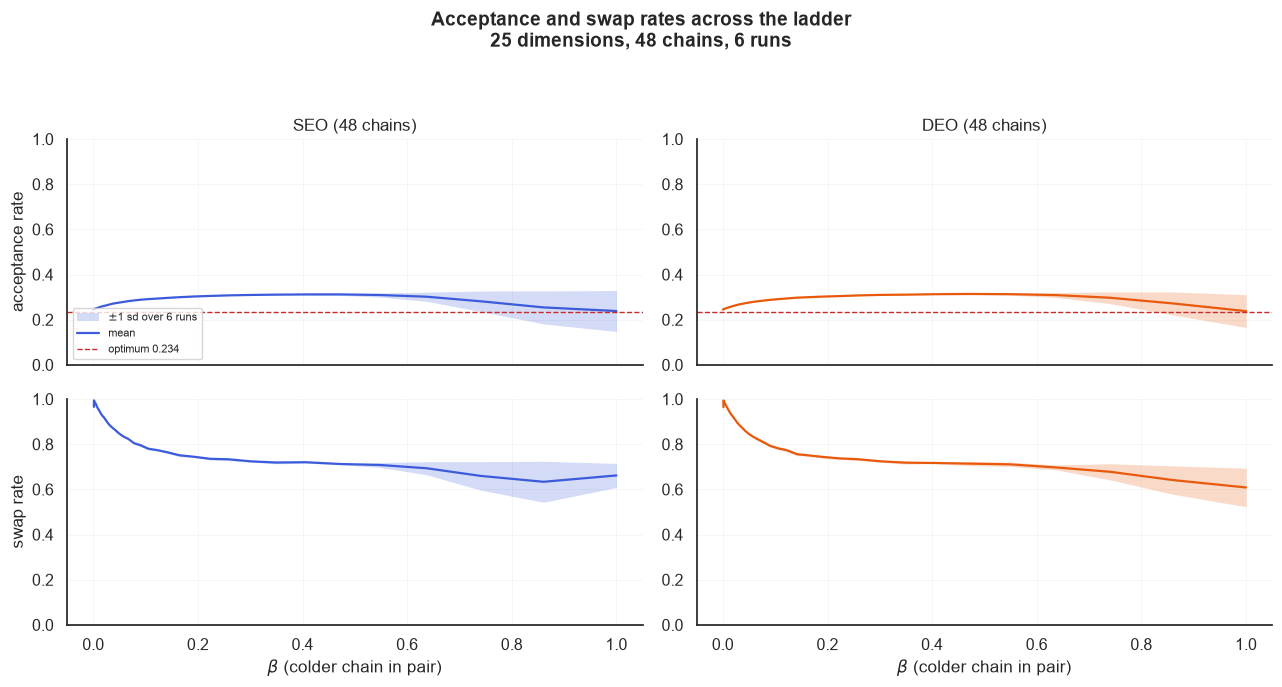

In [199]:
fig_rates, axes_rates = plt.subplots(2, 2, figsize=(13, 7), sharex='col')


def rate_band(ax, x, runs, colour):
    """Mean over the replicate runs, with a +/- 1 sd band."""
    runs = np.asarray(runs)
    mean = runs.mean(axis=0)
    sd = runs.std(axis=0, ddof=1) if runs.shape[0] > 1 else np.zeros_like(mean)
    ax.fill_between(x, mean-sd, mean+sd, color=colour, alpha=0.22, lw=0,
                    label=rf'$\pm$1 sd over {runs.shape[0]} runs')
    ax.plot(x, mean, color=colour, lw=1.6, label='mean')


rate_band(axes_rates[0][0], SEO_beta, accept_SEO_runs, SEO_colour)
rate_band(axes_rates[0][1], DEO_beta, accept_DEO_runs, DEO_colour)
rate_band(axes_rates[1][0], SEO_beta[1:], swap_SEO_runs, SEO_colour)
rate_band(axes_rates[1][1], DEO_beta[1:], swap_DEO_runs, DEO_colour)

axes_rates[0][0].axhline(OPTIMAL_ACCEPTANCE, color=truth_colour, ls='--', lw=1,
                         label=f'optimum {OPTIMAL_ACCEPTANCE}')
axes_rates[0][1].axhline(OPTIMAL_ACCEPTANCE, color=truth_colour, ls='--', lw=1)
axes_rates[0][0].set_title(f'SEO ({len(SEO_beta)} chains)')
axes_rates[0][1].set_title(f'DEO ({len(DEO_beta)} chains)')
axes_rates[0][0].set_ylabel('acceptance rate')
axes_rates[1][0].set_ylabel('swap rate')
axes_rates[0][0].legend(loc='lower left', fontsize=8)
for ax in axes_rates[1]:
    ax.set_xlabel(r'$\beta$ (colder chain in pair)')

for ax in axes_rates.ravel():
    ax.set_ylim(0, 1); ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

fig_rates.suptitle('Acceptance and swap rates across the ladder\n'
                   f'{d} dimensions, {num_chains} chains, {n_runs} runs',
                   fontsize=14, fontweight='bold')
fig_rates.tight_layout(rect=[0, 0, 1, 0.94])
fig_rates.savefig(plot_path('rates.png'))
ALL_FIGS.append(fig_rates)
plt.show()

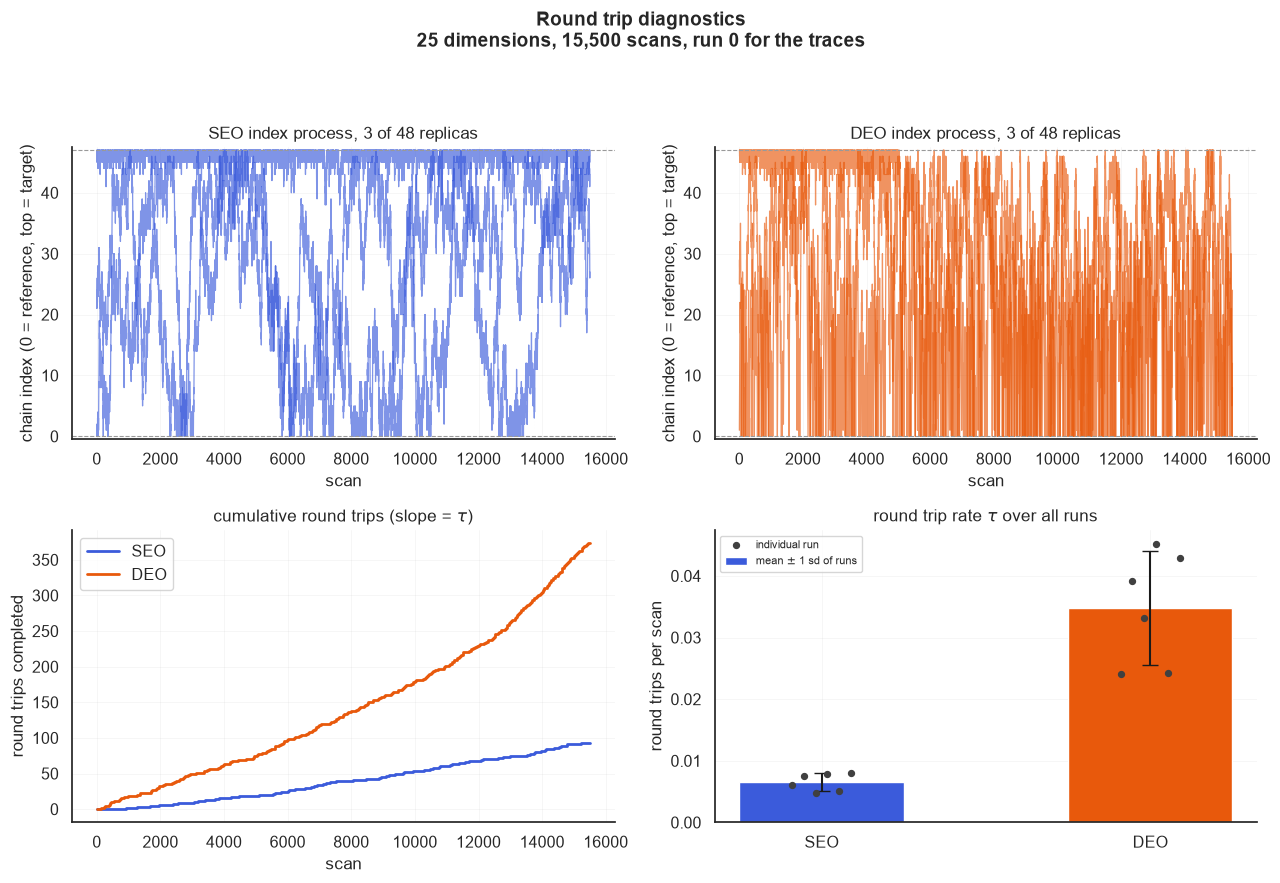

In [200]:
trips_SEO, trip_scans_SEO = round_trip_stats(index_SEO)
trips_DEO, trip_scans_DEO = round_trip_stats(index_DEO)

fig_trips, axes_trips = plt.subplots(2, 2, figsize=(13, 9))

window = min(40_000, iterations)
for ax, (name, index_process, colour) in zip(
        axes_trips[0], [('SEO', index_SEO, SEO_colour), ('DEO', index_DEO, DEO_colour)]):
    n_chains_here = index_process.shape[1]
    for r in [0, n_chains_here//2, n_chains_here-1]:
        ax.plot(index_process[:window, r], lw=0.9, color=colour, alpha=0.65)
    ax.axhline(0, color='0.6', ls='--', lw=0.8)
    ax.axhline(n_chains_here-1, color='0.6', ls='--', lw=0.8)
    ax.set_ylim(-0.5, n_chains_here-0.5)
    ax.set_xlabel('scan'); ax.set_ylabel('chain index (0 = reference, top = target)')
    ax.set_title(f'{name} index process, 3 of {n_chains_here} replicas')

#cumulative round trips: the slope is tau
ax = axes_trips[1][0]
for name, scans_at, colour in [('SEO', trip_scans_SEO, SEO_colour),
                               ('DEO', trip_scans_DEO, DEO_colour)]:
    steps = np.concatenate(([0], scans_at, [iterations]))
    counts = np.concatenate(([0], np.arange(1, len(scans_at)+1), [len(scans_at)]))
    ax.step(steps, counts, where='post', lw=2, color=colour, label=name)
ax.set_xlabel('scan'); ax.set_ylabel('round trips completed')
ax.set_title(r'cumulative round trips (slope = $\tau$)')
ax.legend()

#the rate itself, across all runs
ax = axes_trips[1][1]
means = [tau_SEO_runs.mean(), tau_DEO_runs.mean()]
errors = [tau_SEO_runs.std(ddof=1), tau_DEO_runs.std(ddof=1)]
bars = ax.bar(['SEO', 'DEO'], means, yerr=errors, capsize=6, width=0.5,
              color=[SEO_colour, DEO_colour], label=r'mean $\pm$ 1 sd of runs')
for position, values in zip([0, 1], [tau_SEO_runs, tau_DEO_runs]):
    ax.scatter(position + np.linspace(-0.09, 0.09, n_runs), values,
               s=18, color='0.25', zorder=3,
               label='individual run' if position == 0 else None)
ax.set_ylabel('round trips per scan')
ax.set_title(r'round trip rate $\tau$ over all runs')
ax.legend(fontsize=8)

for ax in axes_trips.ravel():
    ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

fig_trips.suptitle('Round trip diagnostics\n'
                   f'{d} dimensions, {iterations:,} scans, run 0 for the traces',
                   fontsize=14, fontweight='bold')
fig_trips.tight_layout(rect=[0, 0, 1, 0.94])
fig_trips.savefig(plot_path('round_trips.png'))
ALL_FIGS.append(fig_trips)
plt.show()

### The communication barrier


In [201]:
def communication_barrier(beta, swap_rate):
    """Total barrier Lambda and the cumulative curve Lambda(beta)."""
    rejection = 1 - np.asarray(swap_rate)
    beta_grid = np.asarray(beta)
    Lambda_grid = np.concatenate(([0.0], np.cumsum(rejection)))
    return rejection.sum(), beta_grid, Lambda_grid


def theoretical_round_trip_rate(swap_rate):
    """Schedule inefficiency E(P_N) and the round trip rate it predicts."""
    swap_rate = np.asarray(swap_rate, dtype=float)
    N = swap_rate.size
    rejection = 1 - swap_rate

    inefficiency = np.sum(rejection/np.maximum(swap_rate, 1e-12))

    return inefficiency, 1/(2*N + 2*inefficiency), 1/(2 + 2*inefficiency)

In [202]:
swap_SEO_mean = swap_SEO_runs.mean(axis=0)
swap_DEO_mean = swap_DEO_runs.mean(axis=0)

Lambda_SEO, beta_grid_SEO, Lambda_grid_SEO = communication_barrier(SEO_beta, swap_SEO_mean)
Lambda_DEO, beta_grid_DEO, Lambda_grid_DEO = communication_barrier(DEO_beta, swap_DEO_mean)

inefficiency_SEO, tau_SEO_theory, _ = theoretical_round_trip_rate(swap_SEO_mean)
inefficiency_DEO, _, tau_DEO_theory = theoretical_round_trip_rate(swap_DEO_mean)

print('communication barrier, averaged over runs')
print(f'  SEO Lambda              = {Lambda_SEO:.3f}   over {len(SEO_beta)-1} pairs, '
      f'mean rejection {np.mean(1-swap_SEO_mean):.3f}')
print(f'  DEO Lambda              = {Lambda_DEO:.3f}   over {len(DEO_beta)-1} pairs, '
      f'mean rejection {np.mean(1-swap_DEO_mean):.3f}')
print('  both estimate the same path, so they should agree')

print(f'\nschedule inefficiency E(P_N) = sum r/s')
print(f'  SEO                     = {inefficiency_SEO:.3f}')
print(f'  DEO                     = {inefficiency_DEO:.3f}')

print(f'\nround trip rate: theory vs measured')
print(f'  SEO theory              = {tau_SEO_theory:.4f}   measured {tau_SEO_runs.mean():.4f}'
      f'   ({tau_SEO_runs.mean()/max(tau_SEO_theory,1e-12):.2f} x)')
print(f'  DEO theory              = {tau_DEO_theory:.4f}   measured {tau_DEO_runs.mean():.4f}'
      f'   ({tau_DEO_runs.mean()/max(tau_DEO_theory,1e-12):.2f} x)')

print(f'\nasymptotic DEO optimum 1/(2+2*Lambda) = {1/(2+2*Lambda_DEO):.4f}')
print(f'rule of thumb for the chain count, N = 2*Lambda: {2*Lambda_DEO:.0f}')

if tau_DEO_runs.mean() < 0.3*tau_DEO_theory:
    print('\nMeasured tau is far below theory. That gap is the signature of a state')
    print('coordinate that does not refresh between swaps, so the observed rejections')
    print('under-state the true barrier. See section 4.')

communication barrier, averaged over runs
  SEO Lambda              = 6.607   over 47 pairs, mean rejection 0.141
  DEO Lambda              = 6.636   over 47 pairs, mean rejection 0.141
  both estimate the same path, so they should agree

schedule inefficiency E(P_N) = sum r/s
  SEO                     = 8.732
  DEO                     = 8.806

round trip rate: theory vs measured
  SEO theory              = 0.0090   measured 0.0066   (0.73 x)
  DEO theory              = 0.0510   measured 0.0348   (0.68 x)

asymptotic DEO optimum 1/(2+2*Lambda) = 0.0655
rule of thumb for the chain count, N = 2*Lambda: 13


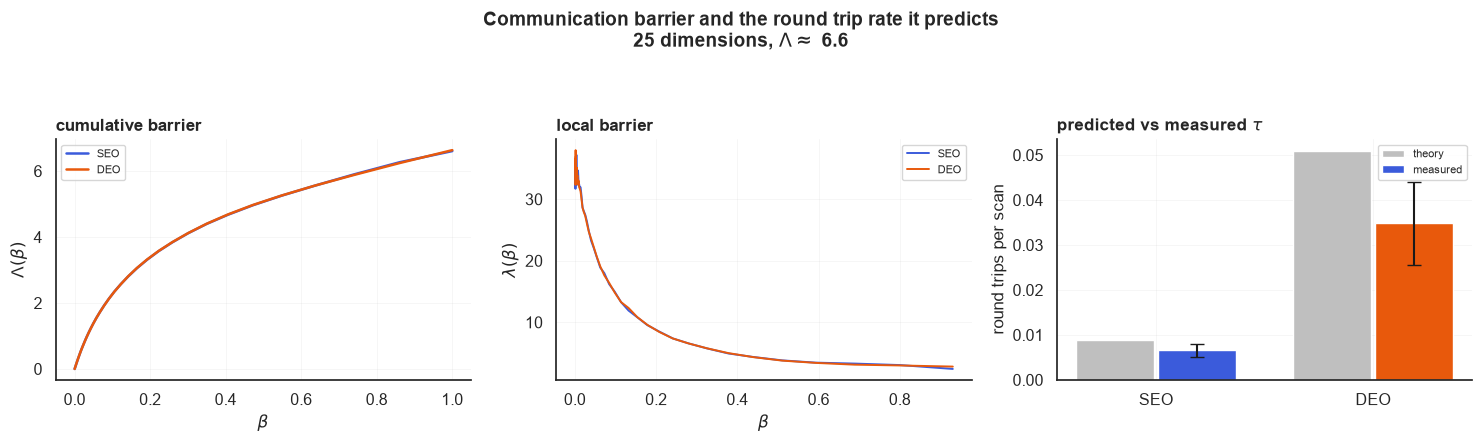

In [203]:
fig_barrier, axes_barrier = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes_barrier[0]
for name, beta_grid, Lambda_grid, colour in [
        ('SEO', beta_grid_SEO, Lambda_grid_SEO, SEO_colour),
        ('DEO', beta_grid_DEO, Lambda_grid_DEO, DEO_colour)]:
    ax.plot(beta_grid, Lambda_grid, color=colour, lw=1.8, label=name)
ax.set_xlabel(r'$\beta$'); ax.set_ylabel(r'$\Lambda(\beta)$')
ax.set_title('cumulative barrier', loc='left', fontweight='bold')
ax.legend(fontsize=8)

ax = axes_barrier[1]
for name, beta_grid, Lambda_grid, colour in [
        ('SEO', beta_grid_SEO, Lambda_grid_SEO, SEO_colour),
        ('DEO', beta_grid_DEO, Lambda_grid_DEO, DEO_colour)]:
    mid = 0.5*(beta_grid[1:] + beta_grid[:-1])
    local = np.diff(Lambda_grid)/np.maximum(np.diff(beta_grid), 1e-12)
    ax.plot(mid, local, color=colour, lw=1.4, label=name)
ax.set_xlabel(r'$\beta$'); ax.set_ylabel(r'$\lambda(\beta)$')
ax.set_title('local barrier', loc='left', fontweight='bold')
ax.legend(fontsize=8)

#predicted against measured
ax = axes_barrier[2]
labels = ['SEO', 'DEO']
theory = [tau_SEO_theory, tau_DEO_theory]
measured = [tau_SEO_runs.mean(), tau_DEO_runs.mean()]
errors = [tau_SEO_runs.std(ddof=1), tau_DEO_runs.std(ddof=1)]
positions = np.arange(2)
ax.bar(positions-0.19, theory, width=0.36, color='0.75', label='theory')
ax.bar(positions+0.19, measured, width=0.36, yerr=errors, capsize=5,
       color=[SEO_colour, DEO_colour], label='measured')
ax.set_xticks(positions); ax.set_xticklabels(labels)
ax.set_ylabel('round trips per scan')
ax.set_title(r'predicted vs measured $\tau$', loc='left', fontweight='bold')
ax.legend(fontsize=8)

for ax in axes_barrier:
    ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

fig_barrier.suptitle('Communication barrier and the round trip rate it predicts\n'
                     rf'{d} dimensions, $\Lambda \approx$ {Lambda_DEO:.1f}',
                     fontsize=14, fontweight='bold')
fig_barrier.tight_layout(rect=[0, 0, 1, 0.92])
fig_barrier.savefig(plot_path('barrier.png'))
ALL_FIGS.append(fig_barrier)
plt.show()

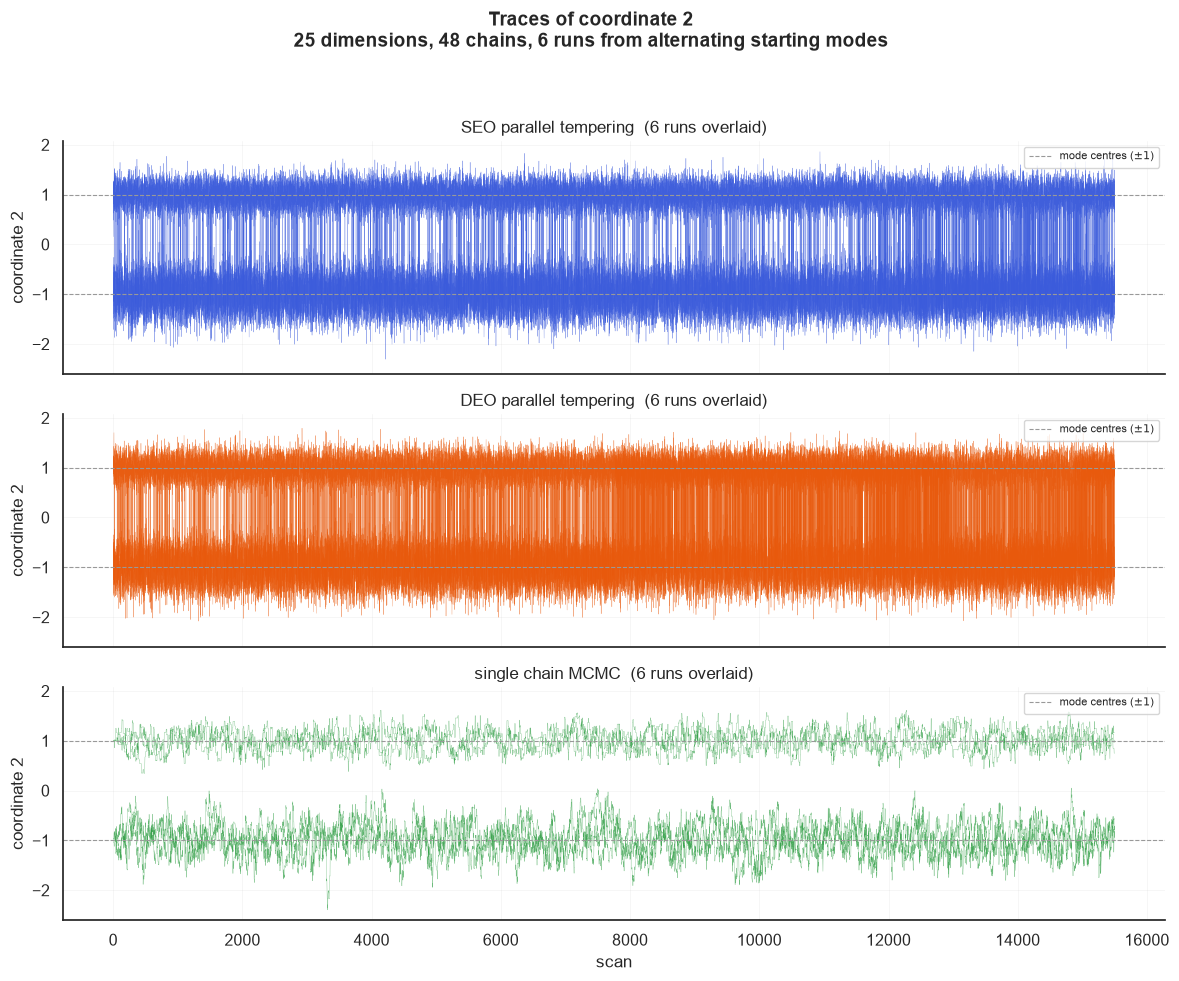

In [204]:
fig_trace, axes_trace = plt.subplots(3, 1, figsize=(12, 10), sharex=True, sharey=True)

for ax, (name, runs, colour) in zip(axes_trace, sampler_rows):
    for r in range(n_runs):
        ax.plot(runs[r][:, coordinate_of_interest], lw=0.25, color=colour, alpha=0.7)
    ax.axhline(+1, color='0.6', ls='--', lw=0.8, label=r'mode centres ($\pm 1$)')
    ax.axhline(-1, color='0.6', ls='--', lw=0.8)
    ax.set_ylabel(f'coordinate {coordinate_of_interest}')
    ax.set_title(f'{name}  ({n_runs} runs overlaid)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

axes_trace[-1].set_xlabel('scan')
fig_trace.suptitle(f'Traces of coordinate {coordinate_of_interest}\n'
                   f'{d} dimensions, {num_chains} chains, {n_runs} runs from '
                   f'alternating starting modes',
                   fontsize=14, fontweight='bold')
fig_trace.tight_layout(rect=[0, 0, 1, 0.95])
fig_trace.savefig(plot_path('traces.png'))
ALL_FIGS.append(fig_trace)
plt.show()

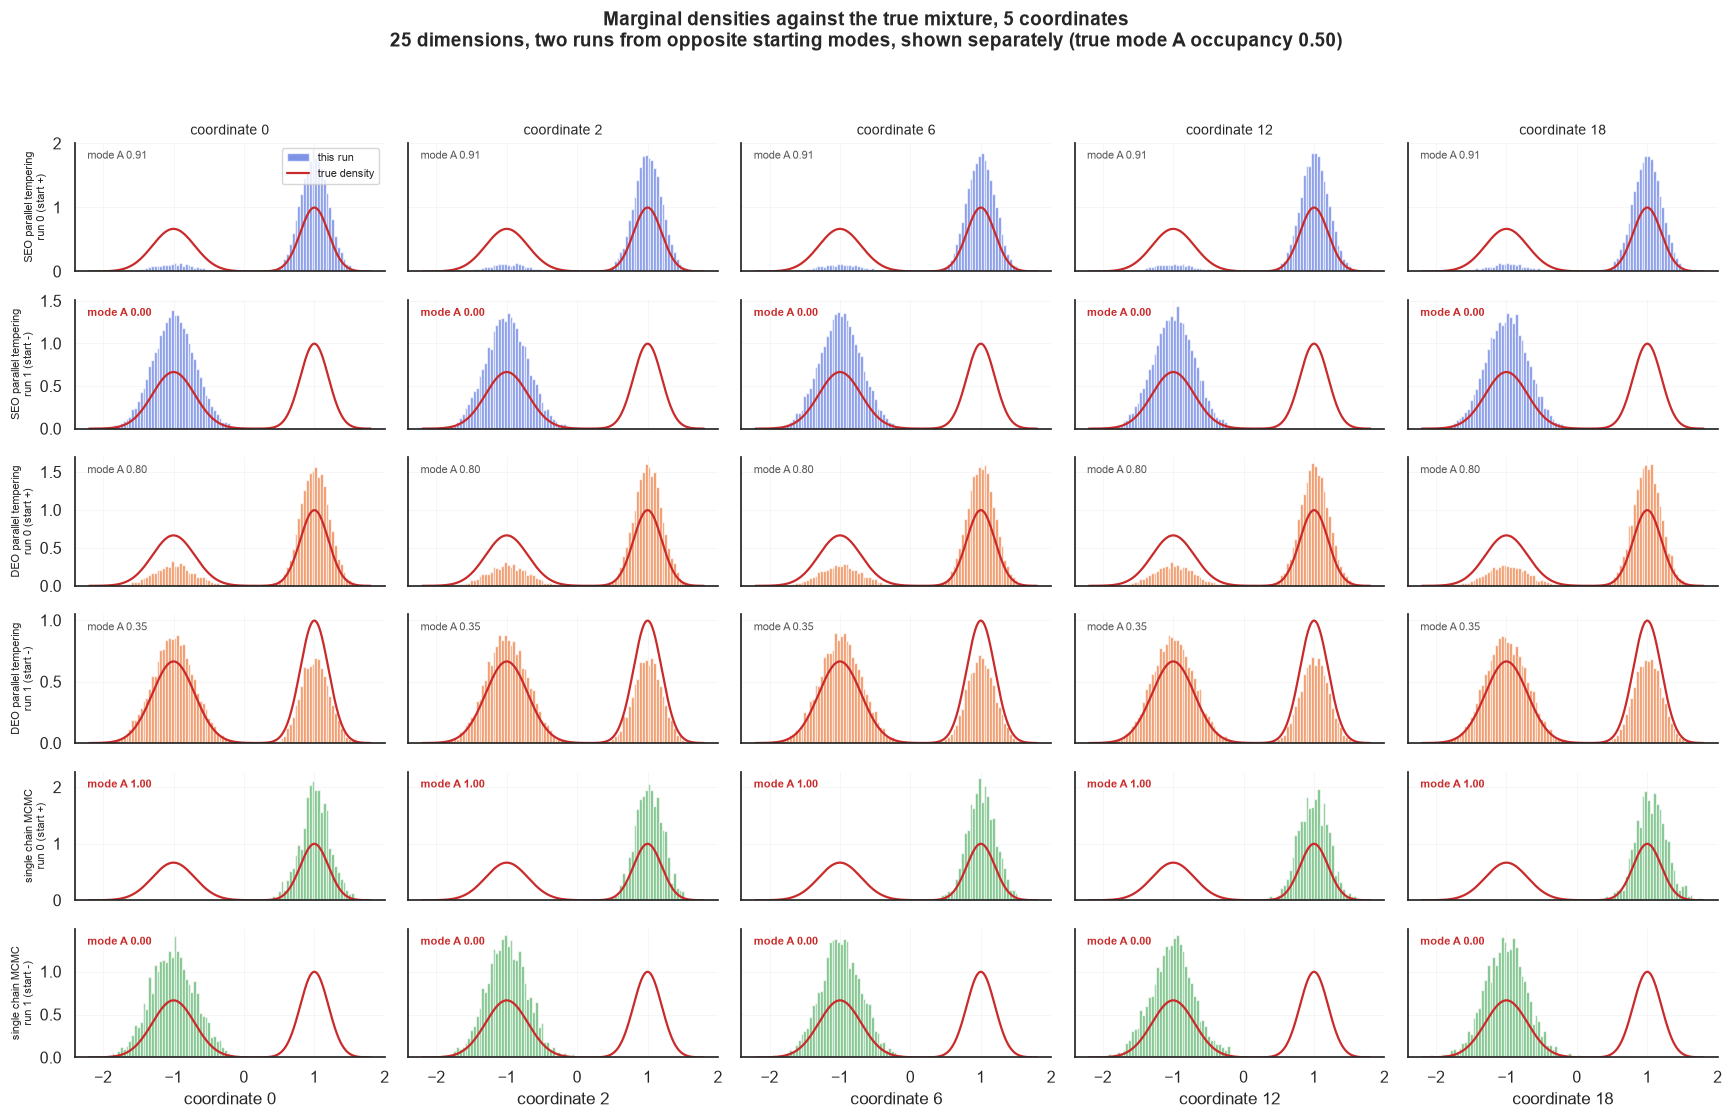

In [205]:
runs_to_show = [0, 1]           #run 0 starts in the + mode, run 1 in the - mode

extra_coordinates = 4
spread = np.linspace(0, d-1, extra_coordinates+1).round().astype(int).tolist()
plot_coordinates = sorted(dict.fromkeys([coordinate_of_interest] + spread))[:extra_coordinates+1]

x_grid = np.linspace(-1-4*s_2, 1+4*s_1, 1000)
true_density = 0.5*norm.pdf(x_grid, loc=1, scale=s_1) + 0.5*norm.pdf(x_grid, loc=-1, scale=s_2)
hist_bins = np.linspace(x_grid[0], x_grid[-1], 101)

#one row per (sampler, run) pair
panel_rows = [(name, runs[r], colour, r)
              for name, runs, colour in sampler_rows
              for r in runs_to_show]

fig_marginal, axes_marginal = plt.subplots(
    len(panel_rows), len(plot_coordinates),
    figsize=(3.5*len(plot_coordinates), 1.9*len(panel_rows)),
    sharex=True, sharey='row', squeeze=False)

for row, (name, samples, colour, run_index) in enumerate(panel_rows):
    start = '+' if start_modes[run_index] > 0 else '-'
    for col, coord in enumerate(plot_coordinates):
        ax = axes_marginal[row][col]
        first = (row == 0 and col == 0)

        ax.hist(samples[:, coord], bins=hist_bins, density=True, alpha=0.65, color=colour,
                label='this run' if first else None)
        ax.plot(x_grid, true_density, color=truth_colour, lw=1.6,
                label='true density' if first else None)

        occupancy = (samples[:, coord] > mode_split).mean()
        trapped = occupancy < 0.05 or occupancy > 0.95
        ax.text(0.04, 0.94, f'mode A {occupancy:.2f}', transform=ax.transAxes,
                va='top', ha='left', fontsize=8,
                color=truth_colour if trapped else '0.35',
                fontweight='bold' if trapped else 'normal')

        if row == 0:
            ax.set_title(f'coordinate {coord}', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{name}\nrun {run_index} (start {start})', fontsize=8)
        if row == len(panel_rows)-1:
            ax.set_xlabel(f'coordinate {coord}')
        ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
        ax.spines[['top', 'right']].set_visible(False)

axes_marginal[0][0].legend(loc='upper right', fontsize=8)
fig_marginal.suptitle('Marginal densities against the true mixture, '
                      f'{len(plot_coordinates)} coordinates\n'
                      f'{d} dimensions, two runs from opposite starting modes, '
                      'shown separately (true mode A occupancy 0.50)',
                      fontsize=14, fontweight='bold')
fig_marginal.tight_layout(rect=[0, 0, 1, 0.95])
fig_marginal.savefig(plot_path('marginals.png'))
ALL_FIGS.append(fig_marginal)
plt.show()

## 11. Summary page and export


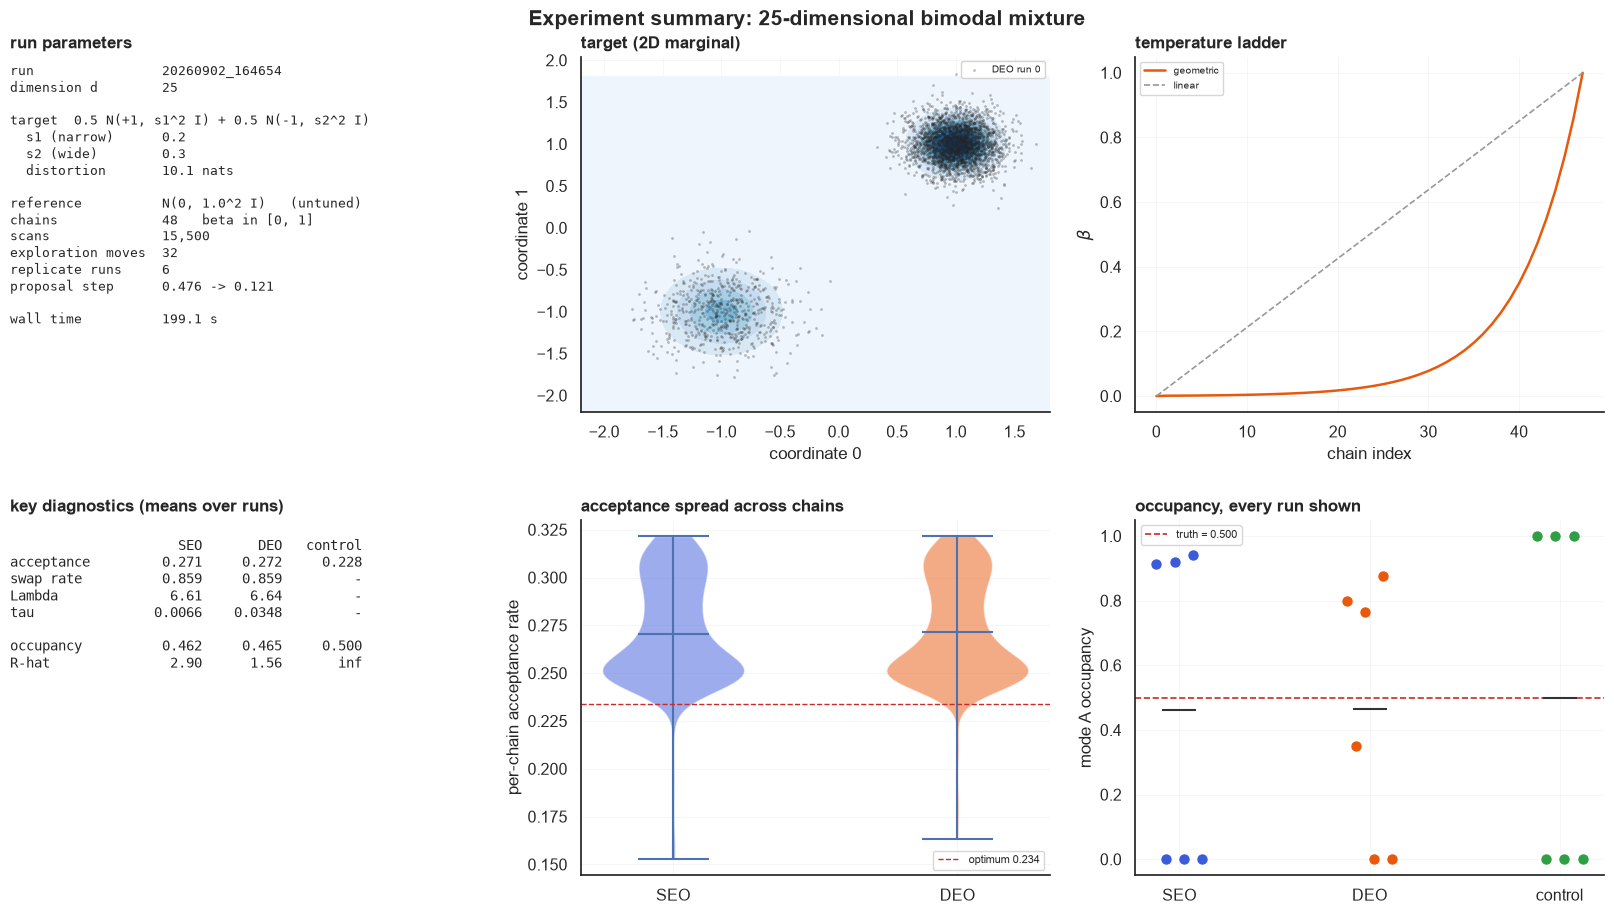

In [206]:
from matplotlib.gridspec import GridSpec

fig_summary = plt.figure(figsize=(16, 9), constrained_layout=True)
fig_summary.get_layout_engine().set(w_pad=0.03, h_pad=0.03, wspace=0.05, hspace=0.08)
gs = GridSpec(2, 3, figure=fig_summary)

#run parameters, for bookkeeping
ax_info = fig_summary.add_subplot(gs[0, 0]); ax_info.axis('off')
reference_name = f'N(0, {sigma_0}^2 I)   (untuned)'
info = [
    f'run                {stamp}',
    f'dimension d        {d}',
    '',
    'target  0.5 N(+1, s1^2 I) + 0.5 N(-1, s2^2 I)',
    f'  s1 (narrow)      {s_1}',
    f'  s2 (wide)        {s_2}',
    f'  distortion       {mode_weight_distortion:.1f} nats',
    '',
    f'reference          {reference_name}',
    f'chains             {num_chains}   beta in [{SEO_beta[0]:.3g}, {SEO_beta[-1]:.3g}]',
    f'scans              {iterations:,}',
    f'exploration moves  {exploration_moves}',
    f'replicate runs     {n_runs}',
    f'proposal step      {proposal_scale(0.0):.3f} -> {proposal_scale(1.0):.3f}',
    '',
    f'wall time          {simulation_time:.1f} s',
]
ax_info.text(0.0, 0.98, '\n'.join(info), transform=ax_info.transAxes,
             va='top', ha='left', family='monospace', fontsize=9.5)
ax_info.set_title('run parameters', loc='left', fontweight='bold')

#the target, as a 2D marginal
ax_target = fig_summary.add_subplot(gs[0, 1])
grid_1d = np.linspace(-1-4*s_2, 1+4*s_1, 200)
X, Y = np.meshgrid(grid_1d, grid_1d)
Z = (0.5*norm.pdf(X, loc=1, scale=s_1)*norm.pdf(Y, loc=1, scale=s_1)
     + 0.5*norm.pdf(X, loc=-1, scale=s_2)*norm.pdf(Y, loc=-1, scale=s_2))
ax_target.contourf(X, Y, Z, levels=12, cmap='Blues')
ax_target.scatter(samples_DEO_runs[0][::5, 0], samples_DEO_runs[0][::5, 1],
                  s=4, color='0.15', alpha=0.3, linewidths=0, label='DEO run 0')
ax_target.set_xlabel('coordinate 0'); ax_target.set_ylabel('coordinate 1')
ax_target.legend(loc='upper right', fontsize=7, framealpha=0.85)
ax_target.set_title('target (2D marginal)', loc='left', fontweight='bold')

#the ladder
ax_sched = fig_summary.add_subplot(gs[0, 2])
ax_sched.plot(np.arange(len(SEO_beta)), SEO_beta, color=DEO_colour, lw=1.8,
              label='geometric')
ax_sched.plot(np.arange(num_chains), np.linspace(0, 1, num_chains),
              color='0.6', ls='--', lw=1.2, label='linear')
ax_sched.set_xlabel('chain index'); ax_sched.set_ylabel(r'$\beta$')
ax_sched.legend(fontsize=7.5)
ax_sched.set_title('temperature ladder', loc='left', fontweight='bold')

#headline numbers
ax_table = fig_summary.add_subplot(gs[1, 0]); ax_table.axis('off')
metrics = [
    f'{"":<14}{"SEO":>10}{"DEO":>10}{"control":>10}',
    f'{"acceptance":<14}{accept_SEO_runs.mean():>10.3f}{accept_DEO_runs.mean():>10.3f}'
    f'{accept_control_runs.mean():>10.3f}',
    f'{"swap rate":<14}{swap_SEO_mean.mean():>10.3f}{swap_DEO_mean.mean():>10.3f}{"-":>10}',
    f'{"Lambda":<14}{Lambda_SEO:>10.2f}{Lambda_DEO:>10.2f}{"-":>10}',
    f'{"tau":<14}{tau_SEO_runs.mean():>10.4f}{tau_DEO_runs.mean():>10.4f}{"-":>10}',
    '',
    f'{"occupancy":<14}{occ_SEO_runs.mean():>10.3f}{occ_DEO_runs.mean():>10.3f}'
    f'{occ_control_runs.mean():>10.3f}',
    f'{"R-hat":<14}{r_hat["SEO"]:>10.2f}{r_hat["DEO"]:>10.2f}'
    f'{r_hat["single chain"]:>10.2f}',
]
ax_table.text(0.0, 0.95, '\n'.join(metrics), transform=ax_table.transAxes,
              va='top', ha='left', family='monospace', fontsize=10)
ax_table.set_title('key diagnostics (means over runs)', loc='left', fontweight='bold')

#acceptance spread across chains
ax_violin = fig_summary.add_subplot(gs[1, 1])
parts = ax_violin.violinplot([accept_SEO_runs.ravel(), accept_DEO_runs.ravel()],
                             showmeans=True)
for body, colour in zip(parts['bodies'], [SEO_colour, DEO_colour]):
    body.set_facecolor(colour); body.set_alpha(0.5)
ax_violin.axhline(OPTIMAL_ACCEPTANCE, color=truth_colour, ls='--', lw=1,
                  label=f'optimum {OPTIMAL_ACCEPTANCE}')
ax_violin.set_xticks([1, 2]); ax_violin.set_xticklabels(['SEO', 'DEO'])
ax_violin.set_ylabel('per-chain acceptance rate'); ax_violin.legend(fontsize=8)
ax_violin.set_title('acceptance spread across chains', loc='left', fontweight='bold')

#occupancy per run against the truth
ax_occ = fig_summary.add_subplot(gs[1, 2])
for position, (name, values, colour) in enumerate(
        [('SEO', occ_SEO_runs, SEO_colour), ('DEO', occ_DEO_runs, DEO_colour),
         ('control', occ_control_runs, control_colour)]):
    ax_occ.scatter(np.full(n_runs, position) + np.linspace(-0.12, 0.12, n_runs),
                   values, s=42, color=colour, zorder=3)
    ax_occ.scatter([position], [values.mean()], marker='_', s=600, color='0.2', zorder=4)
ax_occ.axhline(0.5, color=truth_colour, ls='--', lw=1.2, label='truth = 0.500')
ax_occ.set_xticks([0, 1, 2]); ax_occ.set_xticklabels(['SEO', 'DEO', 'control'])
ax_occ.set_ylim(-0.05, 1.05); ax_occ.set_ylabel('mode A occupancy')
ax_occ.legend(fontsize=8)
ax_occ.set_title('occupancy, every run shown', loc='left', fontweight='bold')

for ax in (ax_target, ax_sched, ax_violin, ax_occ):
    ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

fig_summary.suptitle(f'Experiment summary: {d}-dimensional bimodal mixture',
                     fontsize=15, fontweight='bold')
fig_summary.savefig(plot_path('summary.png'))
ALL_FIGS.append(fig_summary)
plt.show()

In [207]:
def run_label():
    """One line describing the run, stamped onto every saved page."""
    reference_name = f'N(0,{sigma_0}^2)'
    return (f'run {stamp}   |   d = {d}   |   {num_chains} chains   |   '
            f'{iterations} scans x {exploration_moves} moves x {n_runs} runs   |   '
            f'reference {reference_name}   |   s1 = {s_1}, s2 = {s_2}')


def save_all_figures(filename, figs=None):
    """Write the figures to one PDF, stamping each page so it can be traced back."""
    figs = ALL_FIGS if figs is None else figs
    path = plot_path(filename)
    label = run_label()

    stamps = []
    with PdfPages(path) as pdf:
        for position, figure in enumerate(figs, start=1):
            tag = figure.text(0.995, 0.995, f'Figure {position} of {len(figs)}',
                              ha='right', va='top', fontsize=8, color='0.45')
            foot = figure.text(0.005, 0.005, label,
                               ha='left', va='bottom', fontsize=6.5, color='0.55')
            stamps.append((tag, foot))
            pdf.savefig(figure)

    for tag, foot in stamps:
        tag.remove(); foot.remove()

    print(f'saved {len(figs)} figures to {path}')


save_all_figures('all_figures.pdf')

saved 8 figures to output/20260902_164654/all_figures.pdf


## 12. Optional: a cheaper sweep, repeated more often


In [208]:
n_trials = 10
scans_per_trial = max(2000, iterations//20)

occ_SEO_trials = np.zeros(n_trials)
occ_DEO_trials = np.zeros(n_trials)
tau_SEO_trials = np.zeros(n_trials)
tau_DEO_trials = np.zeros(n_trials)

sweep_start = time.time()
for i in range(n_trials):
    seed = 5000 + 10*i
    start_mode = 1 if i % 2 == 0 else -1

    s_SEO, _, _, tau_SEO_trials[i], _ = SEO_parallel_tempering(
        SEO_beta, scans_per_trial, min(exploration_moves, 8),
        rng=np.random.default_rng(seed), init_sign=start_mode)
    s_DEO, _, _, tau_DEO_trials[i], _ = DEO_parallel_tempering(
        DEO_beta, scans_per_trial, min(exploration_moves, 8),
        rng=np.random.default_rng(seed+1), init_sign=start_mode)

    occ_SEO_trials[i] = (s_SEO[:, coordinate_of_interest] > mode_split).mean()
    occ_DEO_trials[i] = (s_DEO[:, coordinate_of_interest] > mode_split).mean()

print(f'{n_trials} trials of {scans_per_trial:,} scans in {time.time()-sweep_start:.1f} s')

10 trials of 2,000 scans in 11.5 s


In [209]:
print(f'mode A occupancy over {n_trials} trials of {scans_per_trial:,} scans')
report_runs('  SEO', occ_SEO_trials, truth=0.5, fmt='.3f')
report_runs('  DEO', occ_DEO_trials, truth=0.5, fmt='.3f')

print(f'\nround trip rate over {n_trials} trials')
report_runs('  SEO', tau_SEO_trials)
report_runs('  DEO', tau_DEO_trials)

print()
for name, values in [('SEO', occ_SEO_trials), ('DEO', occ_DEO_trials)]:
    pinned = np.mean((values < 0.05) | (values > 0.95))
    print(f'{name} trials pinned at one mode: {pinned:.0%}')

mode A occupancy over 10 trials of 2,000 scans
  SEO                      0.999  0.000  1.000  0.000  0.992  0.000  0.994  0.000  0.984  0.000
                           mean 0.497  sd 0.524  sem 0.166   truth 0.500, off by 0.0 sem
  DEO                      0.984  0.000  0.986  0.000  0.998  0.000  0.980  0.000  0.988  0.000
                           mean 0.494  sd 0.520  sem 0.165   truth 0.500, off by 0.0 sem

round trip rate over 10 trials
  SEO                      0.0000  0.0015  0.0000  0.0075  0.0015  0.0025  0.0015  0.0045  0.0005  0.0030
                           mean 0.0022  sd 0.0023  sem 0.0007
  DEO                      0.0060  0.0215  0.0040  0.0230  0.0010  0.0225  0.0060  0.0270  0.0040  0.0235
                           mean 0.0138  sd 0.0104  sem 0.0033

SEO trials pinned at one mode: 100%
DEO trials pinned at one mode: 100%


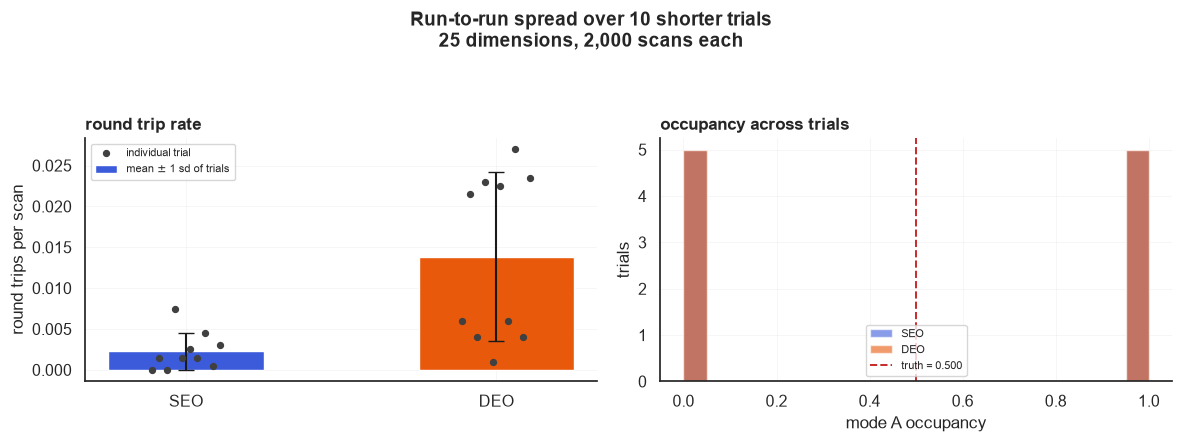

In [210]:
fig_sweep, axes_sweep = plt.subplots(1, 2, figsize=(12, 4.5))

#round trip rate, with every trial shown
ax = axes_sweep[0]
trials = [tau_SEO_trials, tau_DEO_trials]
means = [t.mean() for t in trials]
errors = [t.std(ddof=1) for t in trials]
ax.bar(['SEO', 'DEO'], means, yerr=errors, capsize=6, width=0.5,
       color=[SEO_colour, DEO_colour], label=r'mean $\pm$ 1 sd of trials')
for position, values in zip([0, 1], trials):
    ax.scatter(position + np.linspace(-0.11, 0.11, n_trials), values,
               s=18, color='0.25', zorder=3,
               label='individual trial' if position == 0 else None)
ax.set_ylabel('round trips per scan')
ax.set_title('round trip rate', loc='left', fontweight='bold')
ax.legend(fontsize=8)

ax = axes_sweep[1]
bins = np.linspace(0, 1, 21)
ax.hist(occ_SEO_trials, bins=bins, alpha=0.6, color=SEO_colour, label='SEO')
ax.hist(occ_DEO_trials, bins=bins, alpha=0.6, color=DEO_colour, label='DEO')
ax.axvline(0.5, color=truth_colour, ls='--', lw=1.4, label='truth = 0.500')
ax.set_xlabel('mode A occupancy'); ax.set_ylabel('trials')
ax.set_title('occupancy across trials', loc='left', fontweight='bold')
ax.legend(fontsize=8)

for ax in axes_sweep:
    ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

fig_sweep.suptitle(f'Run-to-run spread over {n_trials} shorter trials\n'
                   f'{d} dimensions, {scans_per_trial:,} scans each',
                   fontsize=14, fontweight='bold')
fig_sweep.tight_layout(rect=[0, 0, 1, 0.92])
fig_sweep.savefig(plot_path('repeat_trials.png'))
plt.show()